In [5]:
include("General.jl")
include("e+e-toDDbar.jl")
include("NumIntegrate.jl")

LoadError: LoadError: UndefVarError: `Nnode` not defined
in expression starting at /Users/heihao/Desktop/DDbarCal/e+e-toDDbar.jl:111

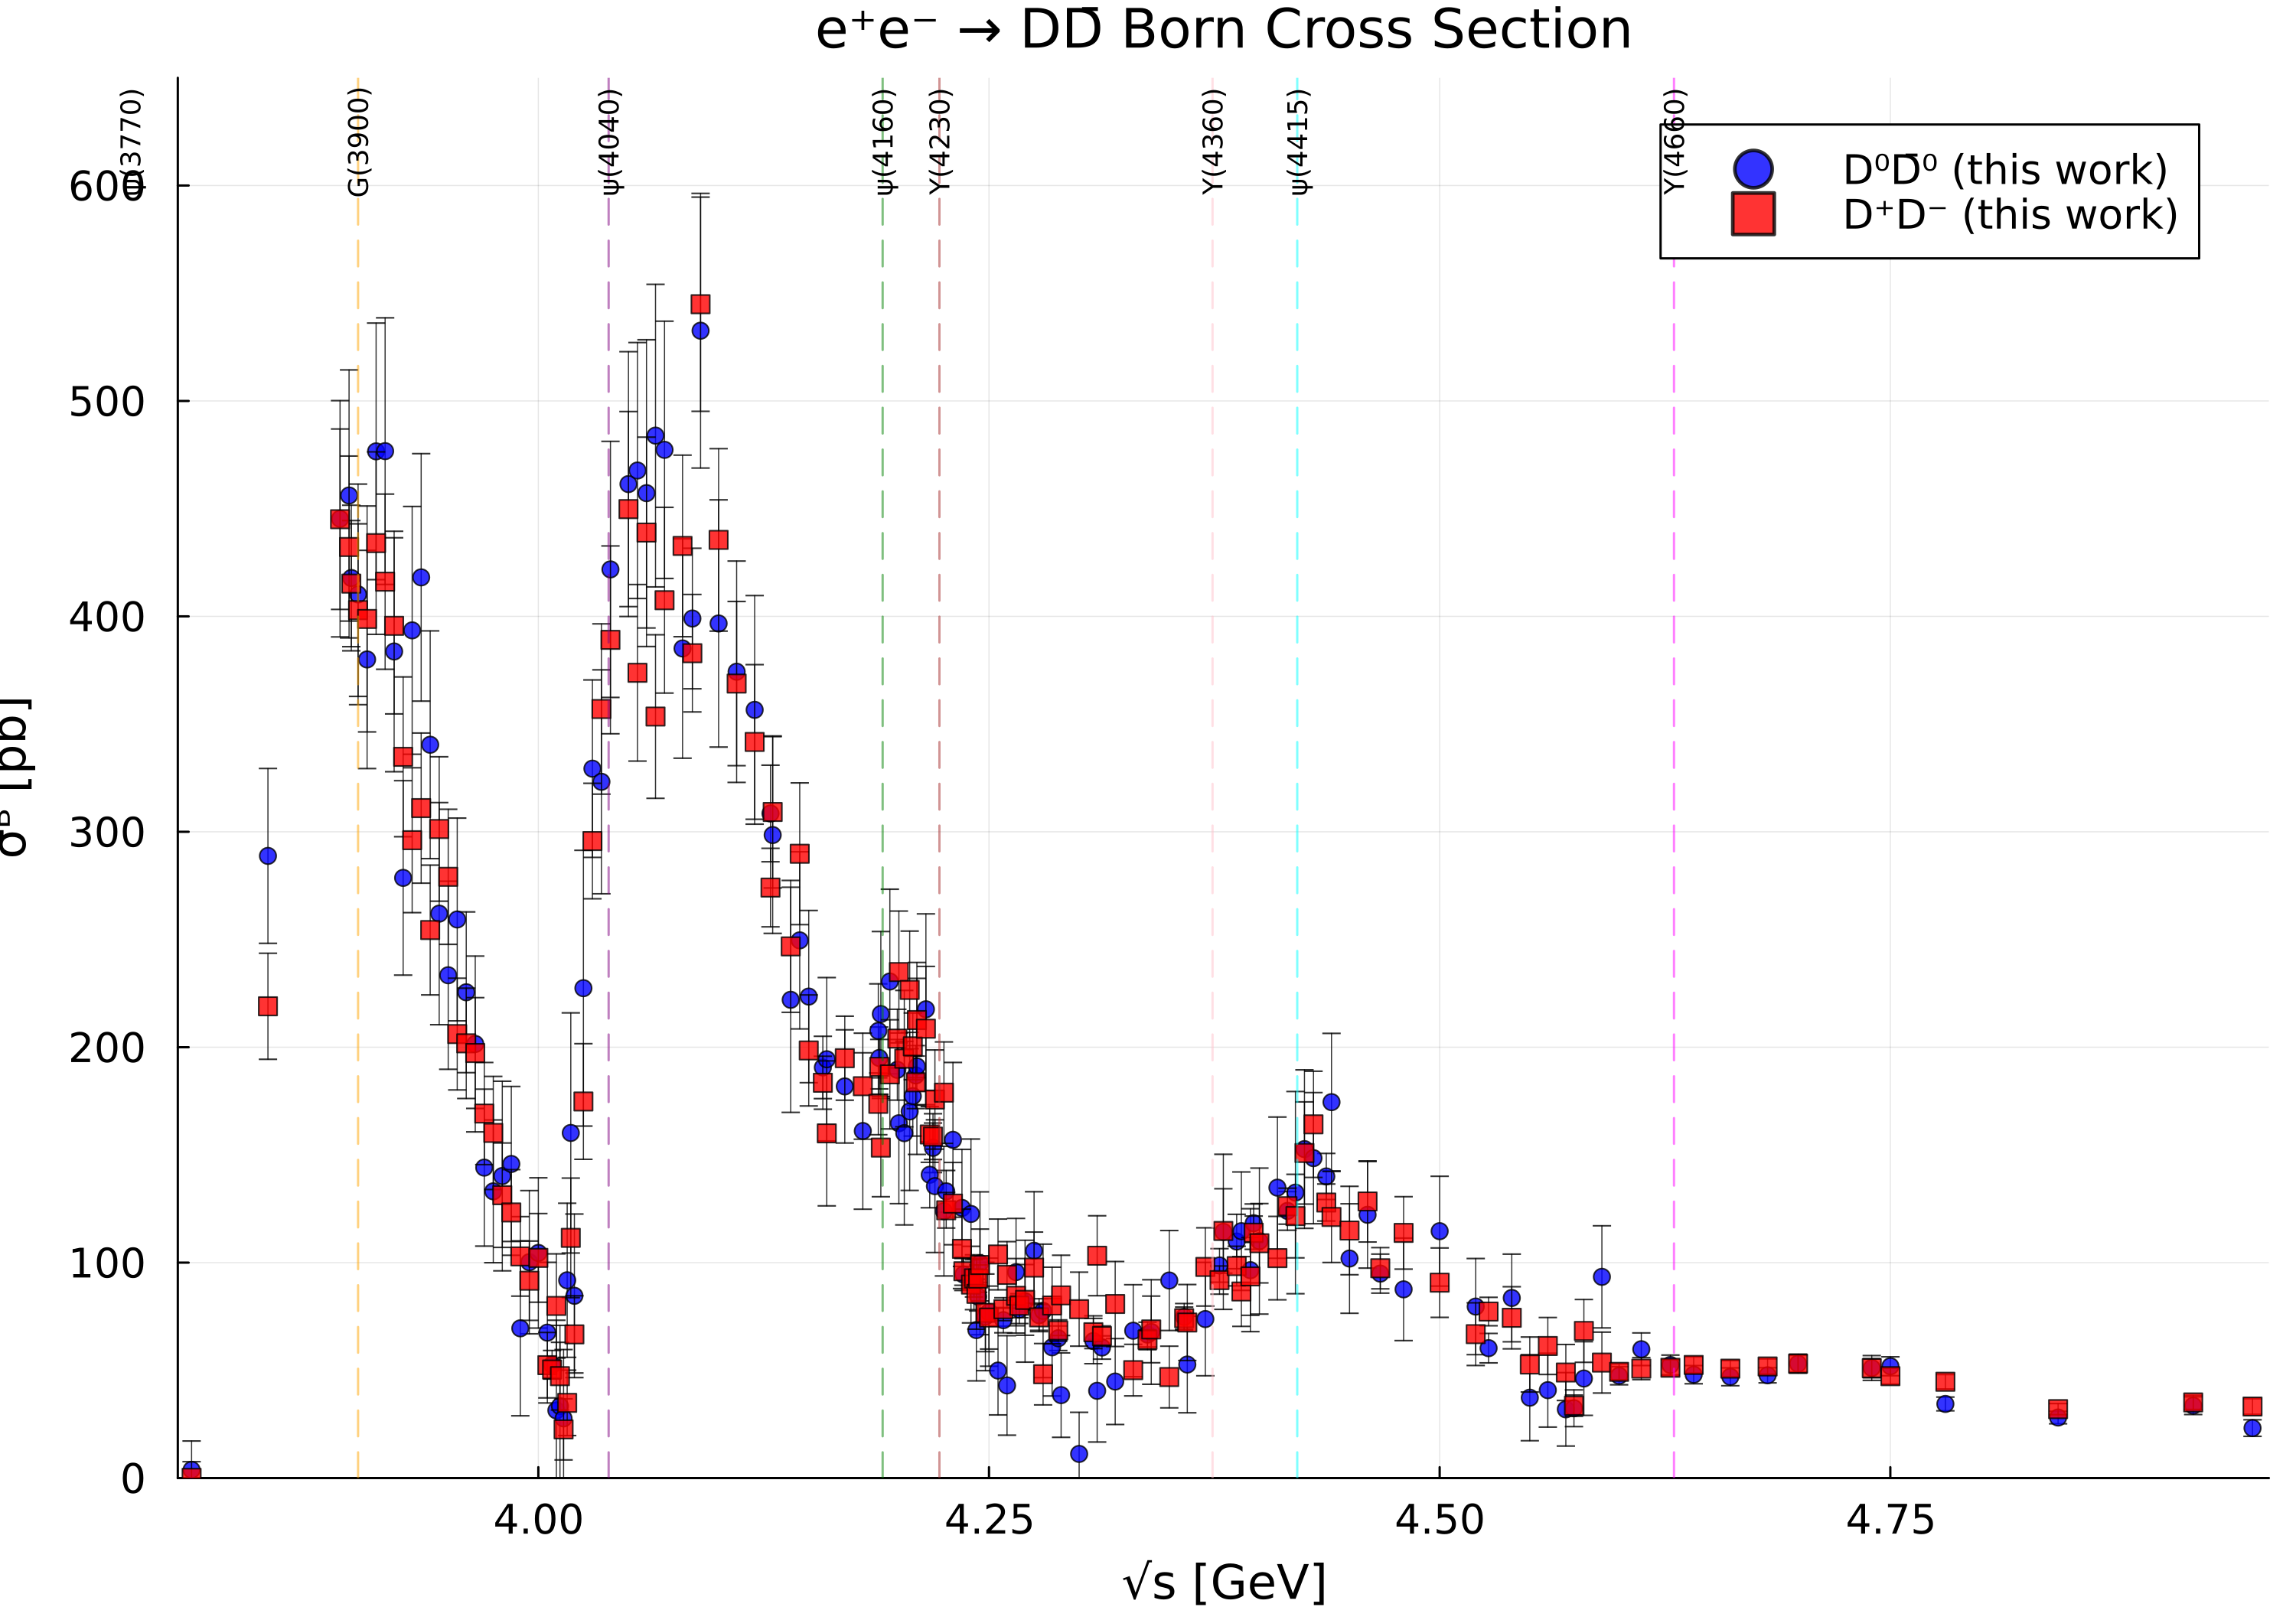

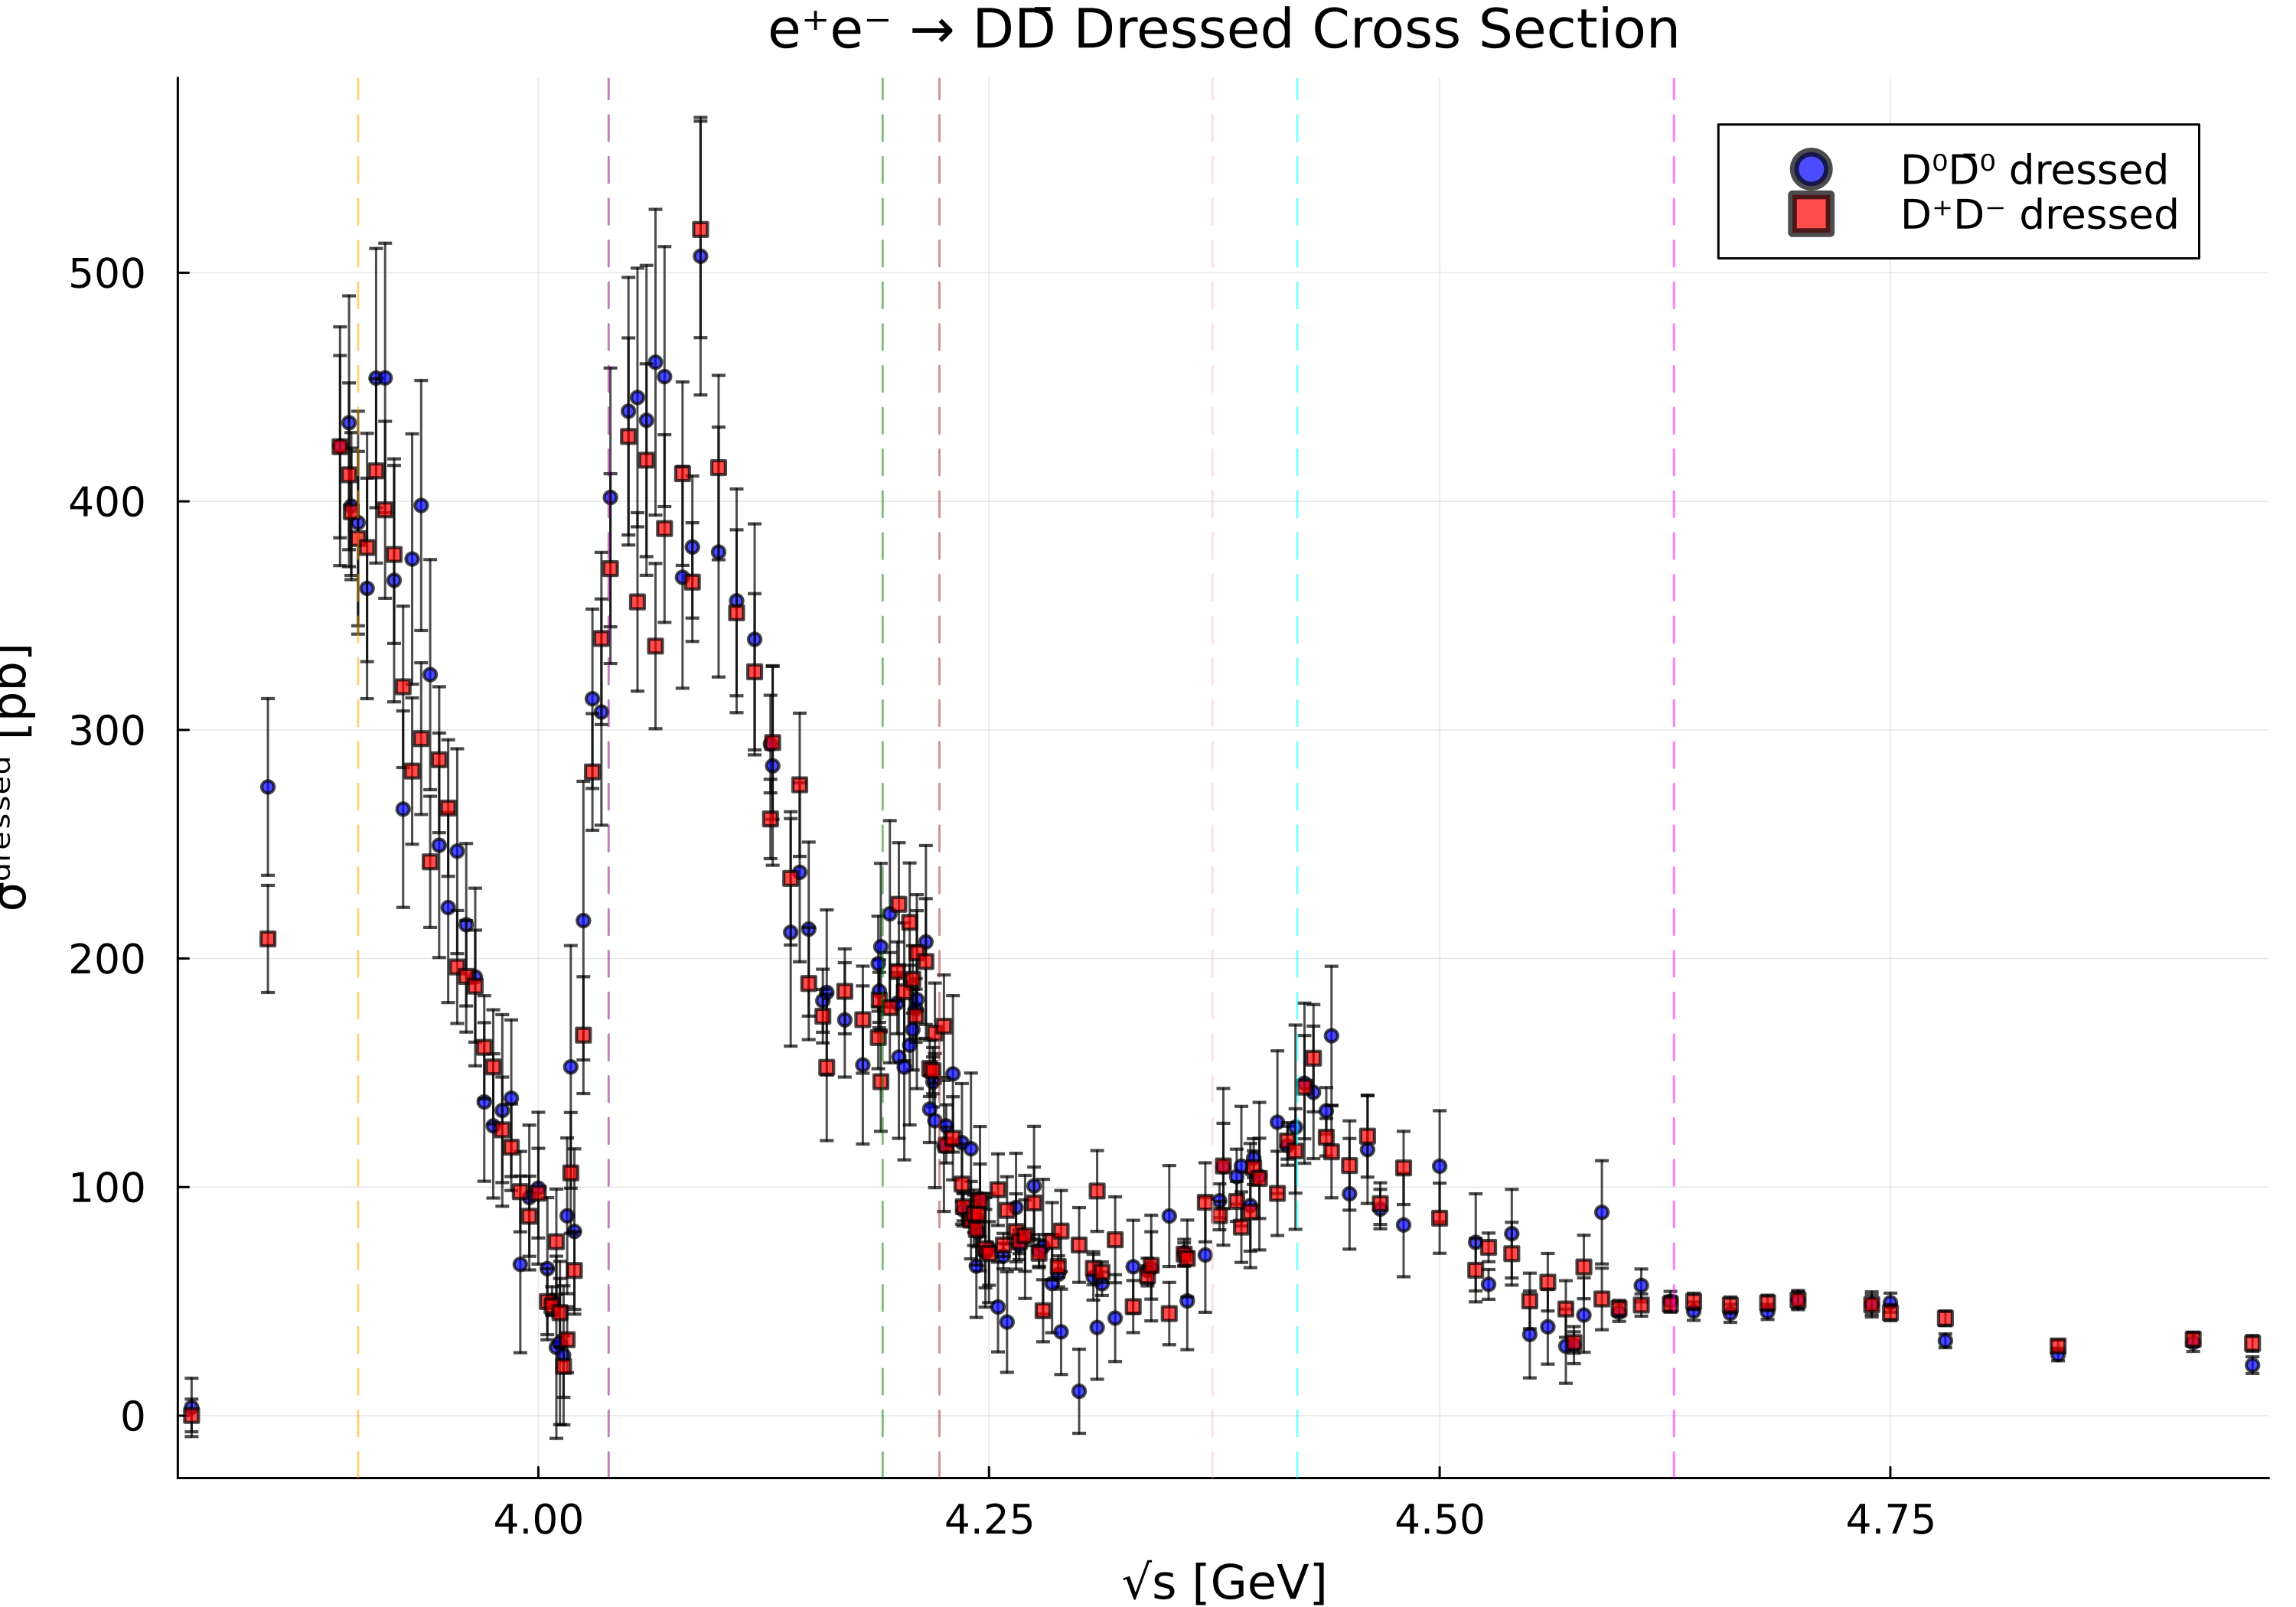

图片已保存为 DDbar_cross_section.pdf 和 DDbar_cross_section.png
Dressed截面图已保存


In [9]:
using Plots
using Printf

# =============== D0D0bar 实验数据 ===============
D0_data = [
    # sqrt(s) [GeV], sigma_B [pb], sigma_B_err_stat [pb], sigma_B_err_sys [pb]
    3.80765 3.8 13.4 0.3
    3.85000 288.8 35.2 20.2
    3.89000 445.3 45.1 31.2
    3.89500 456.1 48.8 31.9
    3.89624 417.8 17.0 29.2
    3.90000 410.2 42.4 28.7
    3.90500 380.0 43.1 26.6
    3.91000 476.6 49.3 33.4
    3.91500 476.7 52.1 33.4
    3.92000 383.7 48.9 26.9
    3.92500 278.6 40.7 19.5
    3.93000 393.5 50.5 27.5
    3.93500 418.1 49.4 29.3
    3.94000 340.4 47.2 23.8
    3.94500 262.0 48.2 18.3
    3.95000 233.4 40.5 16.3
    3.95500 259.3 43.4 18.2
    3.96000 225.5 33.8 15.8
    3.96500 201.5 38.3 14.1
    3.97000 144.1 35.0 10.1
    3.97500 133.1 31.8 9.3
    3.98000 140.2 42.9 9.8
    3.98500 145.8 34.5 10.2
    3.99000 69.5 40.3 4.9
    3.99500 100.2 32.5 7.0
    4.00000 104.5 34.1 7.3
    4.00500 67.5 32.3 4.7
    4.00762 52.6 5.5 3.7
    4.01000 31.4 41.8 2.2
    4.01200 33.4 37.4 2.3
    4.01400 27.7 31.9 1.9
    4.01600 91.8 35.2 6.4
    4.01800 160.2 54.6 11.2
    4.02000 84.6 37.5 5.9
    4.02500 227.4 62.0 15.9
    4.03000 329.3 34.1 23.1
    4.03500 323.2 46.8 22.6
    4.04000 421.8 51.6 29.5
    4.05000 461.4 52.3 32.3
    4.05500 467.7 49.6 32.7
    4.06000 457.2 63.6 32.0
    4.06500 483.9 61.5 33.9
    4.07000 477.3 49.5 33.4
    4.08000 385.1 43.2 27.0
    4.08545 399.0 16.9 27.9
    4.09000 532.6 51.7 37.3
    4.10000 396.7 50.2 27.8
    4.11000 374.3 44.2 26.2
    4.12000 356.6 46.8 25.0
    4.12878 308.5 6.0 21.6
    4.13000 298.5 40.6 20.9
    4.14000 222.0 49.9 15.5
    4.14500 249.6 37.2 17.5
    4.15000 223.5 36.8 15.6
    4.15783 190.6 5.7 13.3
    4.16000 194.4 35.4 13.6
    4.17000 181.8 23.0 12.7
    4.18000 161.1 34.5 11.3
    4.18859 207.6 16.3 14.5
    4.18912 195.0 4.6 13.6
    4.19000 215.4 35.2 15.1
    4.19500 230.5 39.7 16.1
    4.19915 189.5 4.6 13.3
    4.20000 164.7 35.5 11.5
    4.20300 160.1 41.1 11.2
    4.20600 170.2 34.7 11.9
    4.20773 177.3 13.8 12.4
    4.20939 186.9 4.5 13.1
    4.21000 191.1 38.6 13.4
    4.21500 217.6 41.6 15.2
    4.21713 140.8 11.7 9.9
    4.21893 153.3 4.2 10.7
    4.22000 135.5 29.3 9.5
    4.22500 123.9 28.8 8.7
    4.22626 133.1 2.7 9.3
    4.23000 157.0 34.2 11.0
    4.23500 125.4 25.7 8.8
    4.23577 94.5 3.4 6.6
    4.24000 122.6 33.7 8.6
    4.24166 90.9 11.0 6.4
    4.24300 68.7 23.1 4.8
    4.24397 84.2 3.0 5.9
    4.24500 99.7 32.4 7.0
    4.24800 75.0 24.6 5.2
    4.25000 77.0 24.5 5.4
    4.25500 49.9 20.3 3.5
    4.25797 73.3 2.9 5.1
    4.26000 43.0 22.9 3.0
    4.26500 95.6 24.0 6.7
    4.26681 78.2 3.4 5.5
    4.27000 82.1 27.7 5.7
    4.27500 105.5 26.4 7.4
    4.27778 75.6 5.5 5.3
    4.28000 77.6 30.5 5.4
    4.28500 60.7 22.2 4.2
    4.28843 64.9 3.5 4.5
    4.29000 38.5 19.4 2.7
    4.30000 11.2 19.3 0.8
    4.30789 63.6 9.5 4.5
    4.31000 40.5 23.6 2.8
    4.31268 60.6 3.4 4.2
    4.32000 44.8 19.7 3.1
    4.33000 68.4 20.8 4.8
    4.33793 66.6 3.3 4.7
    4.34000 67.8 23.8 4.7
    4.35000 91.7 22.3 6.4
    4.35826 74.8 3.4 5.2
    4.36000 52.7 22.1 3.7
    4.37000 73.8 25.8 5.2
    4.37788 98.7 3.6 6.9
    4.38000 114.3 35.1 8.0
    4.38740 109.8 10.0 7.7
    4.39000 114.6 26.3 8.0
    4.39500 96.5 27.7 6.8
    4.39683 118.3 3.3 8.3
    4.40000 110.0 33.0 7.7
    4.41000 134.8 31.4 9.4
    4.41558 124.0 2.2 8.7
    4.42000 132.5 46.0 9.3
    4.42500 152.7 35.2 10.7
    4.43000 148.5 28.6 10.4
    4.43710 140.0 4.3 9.8
    4.44000 174.5 29.5 12.2
    4.45000 101.9 24.4 7.1
    4.46000 122.2 23.2 8.6
    4.46706 94.9 6.2 6.6
    4.48000 87.6 23.0 6.1
    4.50000 114.6 24.2 8.0
    4.52000 79.6 21.6 5.6
    4.52714 60.3 5.4 4.2
    4.54000 83.6 19.5 5.8
    4.55000 37.3 19.8 2.6
    4.56000 40.8 16.9 2.9
    4.57000 31.9 16.9 2.2
    4.57450 32.4 8.2 2.3
    4.58000 46.2 16.8 3.2
    4.59000 93.4 22.8 6.5
    4.59953 47.5 2.6 3.3
    4.61186 59.8 6.3 4.2
    4.62800 52.5 2.7 3.7
    4.64091 48.0 2.5 3.4
    4.66124 47.0 2.5 3.3
    4.68192 47.7 1.2 3.3
    4.69882 53.1 2.4 3.7
    4.73970 51.1 4.5 3.6
    4.75005 51.9 2.5 3.6
    4.78054 34.4 2.1 2.4
    4.84307 28.1 2.1 2.0
    4.91802 33.6 3.4 2.3
    4.95093 23.2 3.5 1.6
]

# =============== D+D- 实验数据 ===============
# 从PDF表2提取的数据
Dp_data = [
    3.80765 0.1 7.5 0.0
    3.85000 219.0 20.1 14.2
    3.89000 445.1 30.3 28.9
    3.89500 432.2 31.5 28.1
    3.89624 415.2 11.3 27.0
    3.90000 402.9 30.3 26.2
    3.90500 398.8 45.6 25.9
    3.91000 434.0 31.6 28.2
    3.91500 416.1 30.4 27.0
    3.92000 395.6 31.8 25.7
    3.92500 334.8 30.0 21.8
    3.93000 296.1 27.6 19.2
    3.93500 311.0 28.4 20.2
    3.94000 254.4 25.2 16.5
    3.94500 301.3 27.2 19.6
    3.95000 279.1 25.6 18.1
    3.95500 206.1 22.2 13.4
    3.96000 201.8 22.0 13.1
    3.96500 197.3 22.3 12.8
    3.97000 169.2 21.0 11.0
    3.97500 160.2 24.1 10.4
    3.98000 131.3 22.7 8.5
    3.98500 123.3 18.2 8.0
    3.99000 102.9 17.2 6.7
    3.99500 91.6 17.4 6.0
    4.00000 102.2 19.5 6.6
    4.00500 52.4 14.8 3.4
    4.00762 50.4 2.2 3.3
    4.01000 79.9 23.6 5.2
    4.01200 47.3 15.4 3.1
    4.01400 22.6 14.1 1.5
    4.01600 34.9 15.0 2.3
    4.01800 111.5 26.8 7.2
    4.02000 66.7 17.4 4.3
    4.02500 174.8 24.3 11.4
    4.03000 295.7 18.7 19.2
    4.03500 357.0 32.0 23.2
    4.04000 389.1 35.5 25.3
    4.05000 449.8 34.6 29.2
    4.05500 373.8 33.0 24.3
    4.06000 438.9 33.9 28.5
    4.06500 353.5 30.2 23.0
    4.07000 407.5 34.0 26.5
    4.08000 432.7 31.4 28.1
    4.08545 382.9 11.1 24.9
    4.09000 544.9 34.9 35.4
    4.10000 435.5 31.5 28.3
    4.11000 368.8 29.6 24.0
    4.12000 341.7 28.2 22.2
    4.12878 274.1 3.9 17.8
    4.13000 309.2 29.0 20.1
    4.14000 246.8 26.1 16.0
    4.14500 289.8 27.0 18.8
    4.15000 198.5 22.3 12.9
    4.15783 183.5 3.1 11.9
    4.16000 160.0 32.0 10.4
    4.17000 194.9 14.8 12.7
    4.18000 181.9 21.6 11.8
    4.18859 173.7 8.8 11.3
    4.18912 190.9 2.8 12.4
    4.19000 153.4 20.5 10.0
    4.19500 187.4 22.2 12.2
    4.19915 204.0 2.9 13.3
    4.20000 234.9 23.8 15.3
    4.20300 194.7 29.0 12.7
    4.20600 226.6 23.0 14.7
    4.20773 200.4 8.4 13.0
    4.20939 183.7 2.7 11.9
    4.21000 212.6 22.9 13.8
    4.21500 208.6 25.5 13.6
    4.21713 159.5 7.7 10.4
    4.21893 158.5 2.6 10.3
    4.22000 175.7 20.0 11.4
    4.22500 178.9 20.5 11.6
    4.22626 124.3 1.5 8.1
    4.23000 127.4 17.2 8.3
    4.23500 106.4 17.1 6.9
    4.23577 96.0 2.0 6.2
    4.24000 89.8 16.8 5.8
    4.24166 92.7 6.2 6.0
    4.24300 85.5 15.4 5.6
    4.24397 92.6 2.1 6.0
    4.24500 98.9 15.4 6.4
    4.24800 76.7 17.3 5.0
    4.25000 74.5 13.8 4.8
    4.25500 103.8 15.0 6.7
    4.25797 78.4 1.5 5.1
    4.26000 94.3 14.2 6.1
    4.26500 84.6 16.4 5.5
    4.26681 80.0 2.0 5.2
    4.27000 82.7 15.5 5.4
    4.27500 97.7 15.2 6.4
    4.27778 74.6 3.5 4.9
    4.28000 48.2 13.9 3.1
    4.28500 80.1 17.0 5.2
    4.28843 68.5 2.0 4.5
    4.29000 84.8 17.8 5.5
    4.30000 78.4 16.4 5.1
    4.30789 67.7 6.2 4.4
    4.31000 103.2 17.3 6.7
    4.31268 65.9 1.9 4.3
    4.32000 80.8 19.0 5.3
    4.33000 50.1 11.5 3.3
    4.33793 64.2 1.9 4.2
    4.34000 69.0 14.8 4.5
    4.35000 46.9 14.0 3.0
    4.35826 74.2 1.9 4.8
    4.36000 72.2 17.0 4.7
    4.37000 98.0 17.0 6.4
    4.37788 91.9 2.6 6.0
    4.38000 114.7 18.1 7.5
    4.38740 98.4 6.6 6.4
    4.39000 86.6 15.2 5.6
    4.39500 93.6 17.0 6.1
    4.39683 113.9 2.2 7.4
    4.40000 109.0 17.0 7.1
    4.41000 102.1 18.2 6.6
    4.41558 126.2 1.6 8.2
    4.42000 121.6 17.7 7.9
    4.42500 150.9 21.6 9.8
    4.43000 164.2 22.2 10.7
    4.43710 127.9 2.2 8.3
    4.44000 121.2 19.6 7.9
    4.45000 114.9 19.1 7.5
    4.46000 128.4 16.9 8.3
    4.46706 97.4 7.2 6.3
    4.48000 113.8 15.1 7.4
    4.50000 90.7 15.0 5.9
    4.52000 66.8 13.9 4.3
    4.52714 77.3 4.3 5.0
    4.54000 74.4 13.6 4.8
    4.55000 52.7 12.3 3.4
    4.56000 61.3 12.6 4.0
    4.57000 49.0 12.6 3.2
    4.57450 33.6 4.4 2.2
    4.58000 68.3 13.9 4.4
    4.59000 53.6 13.7 3.5
    4.59953 49.3 1.8 3.2
    4.61186 50.8 3.9 3.3
    4.62800 51.2 1.7 3.3
    4.64091 52.5 1.6 3.4
    4.66124 50.8 1.7 3.3
    4.68192 51.8 0.9 3.4
    4.69882 53.1 1.6 3.5
    4.73970 51.0 3.0 3.3
    4.75005 47.3 2.0 3.1
    4.78054 44.7 1.7 2.9
    4.84307 32.0 1.5 2.1
    4.91802 35.1 2.3 2.3
    4.95093 33.2 2.9 2.2
]

# =============== 数据处理 ===============
# 计算总误差 (统计误差和系统误差的平方和开根号)
D0_sqrt_s = D0_data[:, 1]
D0_sigma = D0_data[:, 2]
D0_err = sqrt.(D0_data[:, 3].^2 .+ D0_data[:, 4].^2)

Dp_sqrt_s = Dp_data[:, 1]
Dp_sigma = Dp_data[:, 2]
Dp_err = sqrt.(Dp_data[:, 3].^2 .+ Dp_data[:, 4].^2)

# =============== 绘图 ===============
# 设置中文字体(如果可用)
# plot_font = font("Times New Roman", 12)

p = plot(
    xlabel = "√s [GeV]",
    ylabel = "σᴮ [pb]",
    title = "e⁺e⁻ → DD̄ Born Cross Section",
    grid = true,
    legend = :topright,
    size = (1000, 700),
    dpi = 300,
    # 设置坐标轴范围
    xlims = (3.8, 4.96),
    ylims = (0, 650),
    # 使用科学计数法
    tickfontsize = 12,
    labelfontsize = 14,
    titlefontsize = 16,
    legendfontsize = 12,
)

# 绘制 D0D0bar 数据点
scatter!(p, 
    D0_sqrt_s, 
    D0_sigma, 
    yerr = D0_err,
    label = "D⁰D̄⁰ (this work)",
    color = :blue,
    marker = :circle,
    markersize = 4,
    markerstrokewidth = 0.5,
    alpha = 0.8,
)

# 绘制 D+D- 数据点
scatter!(p,
    Dp_sqrt_s,
    Dp_sigma,
    yerr = Dp_err,
    label = "D⁺D⁻ (this work)",
    color = :red,
    marker = :square,
    markersize = 4,
    markerstrokewidth = 0.5,
    alpha = 0.8,
)

# 标注已知共振态位置
resonances = [
    (3.7737, "ψ(3770)", :gray),
    (3.900, "G(3900)", :orange),
    (4.039, "ψ(4040)", :purple),
    (4.191, "ψ(4160)", :green),
    (4.2225, "Y(4230)", :brown),
    (4.374, "Y(4360)", :pink),
    (4.421, "ψ(4415)", :cyan),
    (4.630, "Y(4660)", :magenta),
]

for (mass, name, color) in resonances
    vline!(p, [mass], 
        linestyle = :dash, 
        linewidth = 1.0, 
        color = color, 
        alpha = 0.5,
        label = nothing
    )
    annotate!(p,
        mass,
        620,
        text(name, 8, :black, rotation = 90),
    )
end

# 保存图片
savefig(p, "DDbar_cross_section.pdf")
savefig(p, "DDbar_cross_section.png")

# 显示图片
display(p)

println("图片已保存为 DDbar_cross_section.pdf 和 DDbar_cross_section.png")

# =============== 额外：绘制Dressed截面 ===============
# Dressed截面 = σB / |1-Π|², VP因子约为1.05

p2 = plot(
    xlabel = "√s [GeV]",
    ylabel = "σᵈʳᵉˢˢᵉᵈ [pb]",
    title = "e⁺e⁻ → DD̄ Dressed Cross Section",
    grid = true,
    legend = :topright,
    size = (1000, 700),
    dpi = 300,
    xlims = (3.8, 4.96),
    tickfontsize = 12,
    labelfontsize = 14,
    titlefontsize = 16,
    legendfontsize = 12,
)

# VP因子约为1.05
VP_factor = 1.05

scatter!(p2,
    D0_sqrt_s,
    D0_sigma / VP_factor,
    yerr = D0_err / VP_factor,
    label = "D⁰D̄⁰ dressed",
    color = :blue,
    marker = :circle,
    markersize = 3,
    alpha = 0.7,
)

scatter!(p2,
    Dp_sqrt_s,
    Dp_sigma / VP_factor,
    yerr = Dp_err / VP_factor,
    label = "D⁺D⁻ dressed",
    color = :red,
    marker = :square,
    markersize = 3,
    alpha = 0.7,
)

for (mass, name, color) in resonances
    vline!(p2, [mass], 
        linestyle = :dash, 
        linewidth = 1.0, 
        color = color, 
        alpha = 0.5,
        label = nothing
    )
end

savefig(p2, "DDbar_dressed_cross_section.pdf")
savefig(p2, "DDbar_dressed_cross_section.png")

display(p2)

println("Dressed截面图已保存")

In [ ]:
using Plots
using Printf

# =============== Ds+Ds- XYZ 数据点 (表1) ===============
DsDs_XYZ = [
    4.00764 35.7 6.8 17.9
    4.08545 40.3 8.2 2.2
    4.12840 22.0 2.6 1.2
    4.15740 30.7 2.9 1.8
    4.17803 38.7 1.1 2.1
    4.18864 62.3 10.4 3.4
    4.18885 43.2 2.6 2.3
    4.19895 40.7 2.6 2.3
    4.20775 41.9 8.0 2.5
    4.20925 30.7 2.3 1.9
    4.21715 19.4 5.9 1.4
    4.21875 14.1 1.8 1.0
    4.22621 11.3 1.1 0.8
    4.23575 18.7 1.9 1.2
    4.24175 22.6 5.9 1.4
    4.24385 31.7 2.1 1.9
    4.25808 43.8 1.9 2.3
    4.26685 50.9 2.5 3.1
    4.27771 58.6 4.6 3.6
    4.28795 53.3 2.6 3.2
    4.30784 64.3 9.1 3.6
    4.31215 50.6 2.5 2.8
    4.33745 48.4 2.5 2.7
    4.35826 34.0 2.1 2.2
    4.37737 30.9 2.1 1.9
    4.38740 29.0 6.5 1.7
    4.39645 31.1 2.1 1.9
    4.41558 38.0 1.5 2.2
    4.43622 48.3 2.3 2.6
    4.46706 38.6 4.5 2.1
    4.52708 26.9 3.9 1.4
    4.57450 21.4 5.3 1.2
    4.59953 21.7 1.5 1.2
    4.61186 23.9 3.7 1.4
    4.62800 19.8 1.6 1.2
    4.64091 19.0 1.5 1.0
    4.66124 17.0 1.5 1.1
    4.68192 20.9 0.9 1.2
    4.69882 22.2 1.6 1.2
    4.73970 17.5 2.5 1.1
    4.75005 23.2 1.9 1.4
    4.78054 20.7 1.5 1.3
    4.84307 16.0 1.3 0.9
    4.91802 12.3 1.9 0.7
    4.95093 11.2 2.0 0.6
]

# =============== Ds+Ds- R-scan 数据点 (表2) ===============
DsDs_Rscan = [
    3.938 7.228 0.0 3.0 0.0
    3.943 7.590 22.4 13.1 1.2
    3.948 7.714 5.6 12.4 0.3
    3.953 8.124 60.5 20.4 3.2
    3.958 8.489 57.1 22.0 3.0
    3.963 7.768 88.6 24.1 4.7
    3.968 7.321 85.7 25.7 4.6
    3.973 8.062 125.1 26.0 6.7
    3.978 7.851 248.8 41.8 13.3
    3.982 7.969 133.2 32.2 7.1
    3.988 8.024 145.4 32.8 7.8
    3.993 7.985 231.1 39.0 12.3
    3.998 7.732 194.9 38.2 10.4
    4.003 7.537 274.2 44.3 14.6
    4.008 7.183 332.7 49.9 17.8
    4.010 6.907 386.4 54.0 20.6
    4.012 6.694 427.2 56.0 22.8
    4.014 6.544 517.3 65.2 27.0
    4.016 6.968 546.5 64.4 29.2
    4.018 6.726 556.6 66.1 29.7
    4.023 6.538 547.1 5.9 29.2
    4.028 16.451 484.2 39.9 25.9
    4.033 6.706 473.0 60.1 25.3
    4.038 6.564 336.1 52.3 17.9
    4.048 6.567 119.6 37.0 6.4
    4.053 6.927 144.2 36.7 7.7
    4.058 6.338 146.7 37.7 7.8
    4.063 7.022 71.7 29.6 3.8
    4.068 7.271 61.3 24.9 3.3
    4.078 7.721 94.9 29.6 5.1
    4.088 7.611 56.5 25.0 3.1
    4.098 7.254 52.1 23.7 2.8
    4.108 7.146 21.2 21.8 1.2
    4.118 7.648 45.2 22.1 2.5
    4.128 7.207 33.4 22.4 1.8
    4.138 7.268 93.2 27.1 5.3
    4.143 7.774 32.9 21.3 1.9
    4.148 7.662 52.4 23.8 3.1
    4.158 7.954 75.2 27.7 4.5
    4.168 18.008 47.9 14.9 2.7
    4.178 7.309 42.5 21.7 2.3
    4.188 7.560 64.5 25.4 3.5
    4.193 7.503 28.7 20.2 1.6
    4.198 7.582 52.4 26.2 2.9
    4.201 6.815 37.1 23.1 2.1
    4.204 7.638 82.6 26.0 4.9
    4.208 7.678 48.6 21.5 3.0
    4.213 7.768 20.4 17.5 1.4
    4.218 7.935 38.8 18.9 2.8
    4.223 8.212 10.9 12.1 0.8
    4.228 8.193 0.0 10.3 0.0
    4.233 8.273 37.2 20.0 2.5
    4.238 7.830 30.0 17.8 1.9
    4.241 8.571 46.9 19.3 2.9
    4.243 8.487 27.9 18.0 1.6
    4.246 8.554 23.9 17.7 1.3
    4.248 8.596 43.8 19.7 2.4
    4.253 8.657 60.3 21.1 3.3
    4.258 8.880 75.6 22.5 4.1
    4.263 8.629 87.7 24.5 5.2
    4.268 8.548 60.8 21.0 3.7
    4.273 8.567 26.1 17.8 1.6
    4.278 8.723 60.7 20.2 3.7
    4.283 8.596 59.7 21.7 3.6
    4.288 9.010 86.5 23.5 5.2
    4.298 8.453 48.4 18.5 2.8
    4.308 8.599 90.5 24.3 5.0
    4.318 9.342 73.4 22.1 4.1
    4.328 8.657 33.1 15.9 1.8
    4.338 8.700 33.4 15.2 1.9
    4.348 8.542 39.5 17.1 2.4
    4.358 8.063 76.6 22.7 5.0
    4.368 8.498 26.0 14.9 1.6
    4.378 8.158 42.8 21.5 2.6
    4.388 7.460 29.7 17.3 1.8
    4.393 7.430 34.8 16.5 2.2
    4.398 7.178 18.2 16.3 1.1
    4.408 6.352 106.1 28.8 6.4
    4.418 7.519 56.5 21.5 3.3
    4.423 7.436 33.2 18.7 1.8
    4.428 6.788 46.2 21.3 2.5
    4.438 7.634 48.2 19.3 2.6
    4.448 7.677 44.3 17.6 2.4
    4.458 8.724 45.9 18.7 2.5
    4.478 8.167 57.0 18.4 3.1
    4.498 7.997 33.5 16.4 1.8
    4.518 8.674 41.3 16.8 2.2
    4.538 9.335 62.6 19.1 3.4
    4.548 8.765 32.6 13.2 1.8
    4.558 8.259 42.9 15.9 2.3
    4.568 8.390 31.0 15.2 1.7
    4.578 8.545 12.7 10.8 0.7
    4.588 8.162 42.8 16.2 2.4
]

# =============== 数据处理 ===============
# XYZ数据
XYZ_sqrt_s = DsDs_XYZ[:, 1]
XYZ_sigma = DsDs_XYZ[:, 2]
XYZ_err = sqrt.(DsDs_XYZ[:, 3].^2 .+ DsDs_XYZ[:, 4].^2)

# R-scan数据
Rscan_sqrt_s = DsDs_Rscan[:, 1]
Rscan_sigma = DsDs_Rscan[:, 2]
Rscan_err = sqrt.(DsDs_Rscan[:, 3].^2 .+ DsDs_Rscan[:, 4].^2)

# =============== 图1: DsDs 单独截面 ===============
p1 = plot(
    xlabel = "√s [GeV]",
    ylabel = "σᴮ [pb]",
    title = "e⁺e⁻ → Dₛ⁺Dₛ⁻ Born Cross Section",
    grid = true,
    legend = :topleft,
    size = (1000, 700),
    dpi = 300,
    xlims = (3.92, 4.96),
    ylims = (0, 650),
    tickfontsize = 12,
    labelfontsize = 14,
    titlefontsize = 16,
    legendfontsize = 12,
)

# XYZ数据点 (较稀疏的高精度数据)
scatter!(p1,
    XYZ_sqrt_s,
    XYZ_sigma,
    yerr = XYZ_err,
    label = "DsDs XYZ data",
    color = :blue,
    marker = :circle,
    markersize = 6,
    markerstrokewidth = 1.0,
    alpha = 0.9,
)

# R-scan数据点 (密集的扫描数据)
scatter!(p1,
    Rscan_sqrt_s,
    Rscan_sigma,
    yerr = Rscan_err,
    label = "DsDs R-scan data",
    color = :red,
    marker = :diamond,
    markersize = 4,
    markerstrokewidth = 0.5,
    alpha = 0.7,
)

# 标注共振态
resonances = [
    (3.938, "Thr.", :black),
    (4.040, "ψ(4040)", :purple),
    (4.160, "ψ(4160)", :green),
    (4.230, "Y(4230)", :brown),
    (4.360, "Y(4360)", :pink),
    (4.420, "ψ(4415)", :cyan),
    (4.660, "Y(4660)", :magenta),
]

for (mass, name, color) in resonances
    vline!(p1, [mass],
        linestyle = :dash,
        linewidth = 1.2,
        color = color,
        alpha = 0.5,
        label = nothing
    )
    annotate!(p1,
        mass,
        620,
        text(name, 8, :black, rotation = 90),
    )
end

savefig(p1, "DsDs_cross_section.pdf")
savefig(p1, "DsDs_cross_section.png")
display(p1)

println("DsDs截面图已保存")

# =============== 图2: DsDs阈值附近放大 ===============
p2 = plot(
    xlabel = "√s [GeV]",
    ylabel = "σᴮ [pb]",
    title = "e⁺e⁻ → Dₛ⁺Dₛ⁻ Near Threshold (R-scan)",
    grid = true,
    legend = :topleft,
    size = (1000, 700),
    dpi = 300,
    xlims = (3.93, 4.10),
    ylims = (-30, 650),
    tickfontsize = 12,
    labelfontsize = 14,
    titlefontsize = 16,
    legendfontsize = 12,
)

# 阈值附近的R-scan数据
near_thr = Rscan_sqrt_s .<= 4.10
scatter!(p2,
    Rscan_sqrt_s[near_thr],
    Rscan_sigma[near_thr],
    yerr = Rscan_err[near_thr],
    label = "DsDs R-scan",
    color = :red,
    marker = :diamond,
    markersize = 5,
    markerstrokewidth = 0.5,
    alpha = 0.8,
)

# 标注阈值
vline!(p2, [3.93668],  # Ds+Ds- 阈值 2*mDs = 2*1968.34 = 3936.68 MeV
    linestyle = :dot,
    linewidth = 2.0,
    color = :black,
    label = "Ds threshold"
)

# 标注峰值位置
annotate!(p2, 4.016, 570, text("Peak ≈ 4.016 GeV", 10, :blue))
annotate!(p2, 3.978, 260, text("Peak ≈ 3.978 GeV", 10, :blue))

savefig(p2, "DsDs_near_threshold.pdf")
savefig(p2, "DsDs_near_threshold.png")
display(p2)

println("DsDs阈值图已保存")

# =============== 图3: 三个道的比较 ===============
# 如果需要和之前DDbar数据比较,可以在这里添加

p3 = plot(
    xlabel = "√s [GeV]",
    ylabel = "σᴮ [pb]",
    title = "e⁺e⁻ → DD̄ and Dₛ⁺Dₛ⁻ Cross Sections Comparison",
    grid = true,
    legend = :topleft,
    size = (1200, 800),
    dpi = 300,
    xlims = (3.80, 4.96),
    ylims = (-10, 650),
    tickfontsize = 12,
    labelfontsize = 14,
    titlefontsize = 16,
    legendfontsize = 11,
)

# DsDs数据
scatter!(p3,
    XYZ_sqrt_s, XYZ_sigma, yerr = XYZ_err,
    label = "DsDs (XYZ)",
    color = :blue, marker = :circle, markersize = 5,
    alpha = 0.8,
)

scatter!(p3,
    Rscan_sqrt_s, Rscan_sigma, yerr = Rscan_err,
    label = "DsDs (R-scan)",
    color = :red, marker = :diamond, markersize = 3,
    alpha = 0.6,
)

# 这里可以添加DDbar数据用于比较
# 如果需要，取消注释以下行
# scatter!(p3, D0_sqrt_s, D0_sigma, yerr = D0_err,
#     label = "D0D0bar",
#     color = :green, marker = :utriangle, markersize = 3,
#     alpha = 0.5,
# )
# scatter!(p3, Dp_sqrt_s, Dp_sigma, yerr = Dp_err,
#     label = "D+D-",
#     color = :orange, marker = :dtriangle, markersize = 3,
#     alpha = 0.5,
# )

# 标注共振态
for (mass, name, color) in resonances
    vline!(p3, [mass],
        linestyle = :dash, linewidth = 1.0,
        color = color, alpha = 0.4,
        label = nothing
    )
    annotate!(p3, mass, 640,
        text(name, 7, :black, rotation = 90),
    )
end

savefig(p3, "DsDs_comparison.pdf")
savefig(p3, "DsDs_comparison.png")
display(p3)

println("比较图已保存")

# =============== 输出数据统计 ===============
println("\n========== 数据统计 ==========")
println("XYZ数据点数量: ", length(XYZ_sqrt_s))
println("XYZ能量范围: ", minimum(XYZ_sqrt_s), " - ", maximum(XYZ_sqrt_s), " GeV")
println("XYZ截面范围: ", minimum(XYZ_sigma), " - ", maximum(XYZ_sigma), " pb")
println()
println("R-scan数据点数量: ", length(Rscan_sqrt_s))
println("R-scan能量范围: ", minimum(Rscan_sqrt_s), " - ", maximum(Rscan_sqrt_s), " GeV")
println("R-scan截面范围: ", minimum(Rscan_sigma), " - ", maximum(Rscan_sigma), " pb")

# 找出峰值
Rscan_max_idx = argmax(Rscan_sigma)
XYZ_max_idx = argmax(XYZ_sigma)

println("\nR-scan最大截面: ", Rscan_sigma[Rscan_max_idx], " ± ", Rscan_err[Rscan_max_idx], 
        " pb at √s = ", Rscan_sqrt_s[Rscan_max_idx], " GeV")
println("XYZ最大截面: ", XYZ_sigma[XYZ_max_idx], " ± ", XYZ_err[XYZ_max_idx], 
        " pb at √s = ", XYZ_sqrt_s[XYZ_max_idx], " GeV")